In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

DATA_PATH = '../data/raw'

os.listdir(DATA_PATH)

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [2]:
#  Creating a local variable for the file path that can be accessed throughout the file.
customers = pd.read_csv(f"{DATA_PATH}/olist_customers_dataset.csv")
orders = pd.read_csv(f"{DATA_PATH}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{DATA_PATH}/olist_order_items_dataset.csv")
order_payments = pd.read_csv(f"{DATA_PATH}/olist_order_payments_dataset.csv")
order_reviews =  pd.read_csv(f"{DATA_PATH}/olist_order_reviews_dataset.csv")
products = pd.read_csv(f"{DATA_PATH}/olist_products_dataset.csv")
sellers = pd.read_csv(f"{DATA_PATH}/olist_sellers_dataset.csv")
category_translation = pd.read_csv(f"{DATA_PATH}/product_category_name_translation.csv")
geolocation = pd.read_csv(f"{DATA_PATH}/olist_geolocation_dataset.csv")

In [3]:
# Identifing missing values in all the datasets
print("----Missing Values----")
print("Customers: \n" , customers.isnull().sum())
print("\nOrders: \n" , orders.isnull().sum())
print("\nOrder Items : \n" , order_items.isnull().sum())
print("\nOrder Payments :\n" , order_payments.isnull().sum())
print("\nOrder Reviews :\n" , order_reviews.isnull().sum())
print("\nProducts :\n" , products.isnull().sum())
print("\nSellers :\n" , sellers.isnull().sum())
print("\nCategory Translation :\n" , category_translation.isnull().sum())
print("\nGeolocation :\n" , geolocation.isnull().sum())

----Missing Values----
Customers: 
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Orders: 
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order Items : 
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Order Payments :
 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Order Reviews :
 review_id                      0
order_id                       0
review_score          

In [4]:
'''
We Can see the Orders ,products and Reviews has missing values.
'''

'\nWe Can see the Orders ,products and Reviews has missing values.\n'

In [5]:
# Checking duplicates values in all datasets
print("----Duplicates Values----")
print("Customers:\n" , customers.duplicated().sum())
print("\nOrders:\n" , orders.duplicated().sum())
print("\nOrder Items :\n" , order_items.duplicated().sum())
print("\nOrder Payments :\n" , order_payments.duplicated().sum())
print("\nOrder Reviews :\n" , order_reviews.duplicated().sum())
print("\nProducts :\n" , products.duplicated().sum())
print("\nSellers :\n" , sellers.duplicated().sum())
print("\nCategory Translation :\n" , category_translation.duplicated().sum())
print("\nGeolocation :\n" , geolocation.duplicated().sum())

----Duplicates Values----
Customers:
 0

Orders:
 0

Order Items :
 0

Order Payments :
 0

Order Reviews :
 0

Products :
 0

Sellers :
 0

Category Translation :
 0

Geolocation :
 261831


In [6]:
'''
We can see geolocation has duplicate values.
'''

'\nWe can see geolocation has duplicate values.\n'

In [7]:
# Checking icorrect dataTypes in all datasets
print("----Incorrect Data Type----")
print("Customers:\n" , customers.dtypes)
print("\nOrders:\n" , orders.dtypes)
print("\nOrder Items :\n" , order_items.dtypes)
print("\nOrder Payments :\n" , order_payments.dtypes)
print("\nOrder Reviews :\n" , order_reviews.dtypes)
print("\nProducts :\n" , products.dtypes)
print("\nSellers :\n" , sellers.dtypes)
print("\nCategory Translation :\n" , category_translation.dtypes)
print("\nGeolocation :\n" , geolocation.dtypes)

----Incorrect Data Type----
Customers:
 customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

Orders:
 order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Order Items :
 order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

Order Payments :
 order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

Order Reviews :

In [8]:
'''
Based on ER diagram the order_delivered_carrier_date ,order_delivered_customer_date ,order_estimated_delivery_date ,shipping_limit_date,
review_creation_date ,review_answer_timestamp should be datetime data type.
'''

'\nBased on ER diagram the order_delivered_carrier_date ,order_delivered_customer_date ,order_estimated_delivery_date ,shipping_limit_date,\nreview_creation_date ,review_answer_timestamp should be datetime data type.\n'

In [14]:
# Identifing inconsistent or invalid values

# Checking product weights , length , price
invalid_weight = products[products['product_weight_g'] == 0]
print(f"Products with 0 weight: {len(invalid_weight)}")

invalid_length = products[products['product_length_cm'] == 0]
print(f"Products with 0 length: {len(invalid_length)}")

# Checking Order Item price 
invalid_order_price = order_items[order_items['price']<=0]
print(f"Order Items with 0 price: {len(invalid_order_price)}")

# Checking Order reviews
invalid_order_reviews = order_reviews[(order_reviews['review_score'] < 1) | (order_reviews['review_score'] >5) ]
print(f"Order reviews with less than 1 or more than 5 : {len(invalid_order_reviews)}")

# Check payment values
invalid_payment = order_payments[
    order_payments["payment_value"] < 0
]

print(f"Payments with invalid value: {len(invalid_payment)}")


# Check payment installments
invalid_installments = order_payments[
    order_payments["payment_installments"] <= 0
]

print(f"Payments with invalid installments: {len(invalid_installments)}")

Products with 0 weight: 4
Products with 0 length: 0
Order Items with 0 price: 0
Order reviews with less than 1 or more than 5 : 0
Payments with invalid value: 0
Payments with invalid installments: 2


In [ ]:
'''
We can see that the total number of product with 0 weight in 4 and payments with payments with invalid installments 
2
'''

'\nWe can see that the total number of product with 0 weight in 4\n'


--- Outlier Detection (Price) ---
Q1: 39.9
Q3: 134.9
IQR: 95.0
Upper limit: 277.4
Potential price outliers: 8427


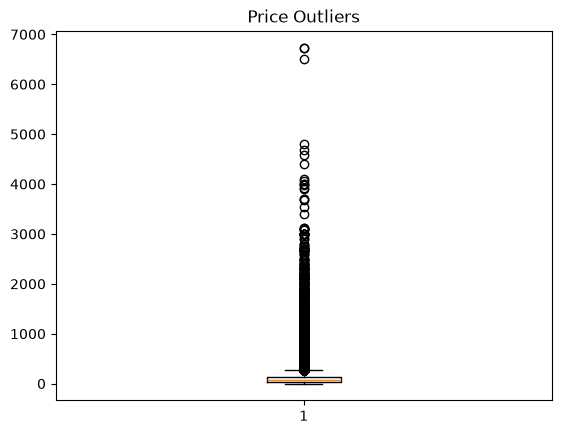

In [11]:
# --- 5. Identify potential outliers ---
print("\n--- Outlier Detection (Price) ---")
# Calculate Q1 and Q3
Q1 = order_items["price"].quantile(0.25)
Q3 = order_items["price"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate upper outlier limit
upper_limit = Q3 + (1.5 * IQR)

# Count potential high-price outliers
outlier_count = (
    order_items["price"] > upper_limit
).sum()

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper limit:", upper_limit)
print("Potential price outliers:", outlier_count)

plt.boxplot(order_items['price'])
plt.title("Price Outliers")
plt.show()


In [12]:
# Check primary-key uniqueness
print("\n--- Primary Key Uniqueness Check ---")
print("\nIs customer ID unique?:" , customers['customer_id'].is_unique)
print("\nIs order ID unique?:" , orders['order_id'].is_unique)
print("\nIs order item ID unique?:" , order_items['order_item_id'].is_unique)
print("\nIs order review ID unique?:" , order_reviews['review_id'].is_unique)
print("\nIs products  ID unique?:" , products['product_id'].is_unique)
print("\nIs sellers ID unique? :" , sellers['seller_id'].is_unique)


--- Primary Key Uniqueness Check ---

Is customer ID unique?: True

Is order ID unique?: True

Is order item ID unique?: False

Is order review ID unique?: False

Is products  ID unique?: True

Is sellers ID unique? : True


In [13]:
''' 
Has we see the order item and order review ID's are not unique
'''

" \nHas we see the order item and order review ID's are not unique\n"